# LRK10L ML model

## Setup

### Imports & installations

In [239]:
%load_ext autoreload
%autoreload 2

from src.evaluation import LOGOEvaluator
from src.pu import run_pu_bagging, PUFilterMixin

import pyhmmer
from pyhmmer.easel import MSAFile, Alphabet
from Bio import SeqIO
import esm
from tqdm.auto import tqdm
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score, StratifiedKFold
from sklearn.metrics import precision_score, recall_score, accuracy_score, average_precision_score, precision_recall_curve, log_loss
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import hypergeom, friedmanchisquare, studentized_range
import scikit_posthocs as sp
import torch
from pathlib import Path
import os
import itertools
from itertools import combinations
import math
from functools import reduce
from collections import Counter

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Helper functions

In [144]:
def clean_gene_id(gene_id: str) -> str:
    return gene_id.split('|')[0]

def get_scale_pos_weight(y):
    return (y == 0).sum() / (y == 1).sum()

### Load HMMs

In [145]:
os.makedirs('../data/hmms', exist_ok=True)

!wget -O ../data/hmms/PF00069.hmm.gz "https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF00069?annotation=hmm"
!gunzip -f ../data/hmms/PF00069.hmm.gz
!file ../data/hmms/PF00069.hmm

!wget -O ../data/hmms/PF07714.hmm.gz "https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF07714?annotation=hmm"
!gunzip -f ../data/hmms/PF07714.hmm.gz
!file ../data/hmms/PF07714.hmm

--2026-08-19 23:22:35--  https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF00069?annotation=hmm
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25382 (25K) [application/gzip]
Saving to: ‘../data/hmms/PF00069.hmm.gz’

../data/hmms/PF0006 100%[===================>]  24.79K  --.-KB/s    in 0.1s    

2026-08-19 23:22:36 (257 KB/s) - ‘../data/hmms/PF00069.hmm.gz’ saved [25382/25382]

../data/hmms/PF00069.hmm: ASCII text
--2026-08-19 23:22:38--  https://www.ebi.ac.uk/interpro/wwwapi/entry/pfam/PF07714?annotation=hmm
Resolving www.ebi.ac.uk (www.ebi.ac.uk)... 193.62.193.80
Connecting to www.ebi.ac.uk (www.ebi.ac.uk)|193.62.193.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 24895 (24K) [application/gzip]
Saving to: ‘../data/hmms/PF07714.hmm.gz’

../data/hmms/PF0771 100%[===================>]  24.31K  --.-KB/s    in 0.1s    


In [146]:
def read_hmms(hmm_dir: Path) -> list[pyhmmer.plan7.HMM]:
    hmms = []
    for hmm_file in hmm_dir.glob('*.hmm'):
        with pyhmmer.plan7.HMMFile(hmm_file) as f:
            hmms.append(f.read())
    return hmms

def search_proteome_for_kinases(proteome_path: Path, hmms: list[pyhmmer.plan7.HMM]) -> set[str]:
    with pyhmmer.easel.SequenceFile(proteome_path, digital=True) as f:
        sequences = f.read_block()

    unique_names = set()
    for hmm in hmms:
        try:
            pipeline = pyhmmer.plan7.Pipeline(hmm.alphabet, bit_cutoffs='gathering')
            hits = pipeline.search_hmm(hmm, sequences)
        except pyhmmer.errors.MissingCutoffs:
            pipeline = pyhmmer.plan7.Pipeline(hmm.alphabet, E=0.001)
            hits = pipeline.search_hmm(hmm, sequences)
        except pyhmmer.errors.AlphabetMismatch:
            print(f'{proteome_path} is not protein, skipped.')
            continue

        for hit in hits.included:
            unique_names.add(clean_gene_id(hit.name))

    return unique_names

hmm_dir = Path('../data/hmms')
hmms = read_hmms(hmm_dir)
print(f'{len(hmms)} HMM(s) loaded')

2 HMM(s) loaded


## Load data

### Load sequences

In [147]:
records = []
record_species = {}

for fname in os.listdir('../data/sequences'):
    species_name = os.path.splitext(fname)[0]

    filepath = os.path.join('../data/sequences', fname)
    with open(filepath) as handle:
        for rec in SeqIO.parse(handle, 'fasta'):
            rec.id = clean_gene_id(rec.id)
            rec.description = ''
            rec.seq = rec.seq.rstrip('*')
            records.append(rec)
            record_species[rec.id] = species_name

print(len(records), 'FASTA records')
print(len(set(record_species.values())), 'unique species')

249635 FASTA records
7 unique species


### Load LRK10L gene IDs

In [148]:
with open('../data/list.txt') as f:
    gene_ids = f.read().strip().split('\n')
gene_ids = set(gene_ids)

print(len(gene_ids), 'LRK10L gene IDs')

367 LRK10L gene IDs


### Check LRK10Ls missing from records

In [149]:
missing = gene_ids - set(rec.id for rec in records)
print(f'{len(missing)} LRK10L gene IDs not found in FASTA records')
if missing:
    print(list(missing)[:10])

0 LRK10L gene IDs not found in FASTA records


## Length filtering

Sequences <250aa cannot be kinases, yet kinase filtering still misses some.

In [150]:
MIN_SEQUENCE_LENGTH = 250
n_records_before = len(records)
records = [rec for rec in records if len(rec.seq) >= MIN_SEQUENCE_LENGTH]
record_species = {rec.id: record_species[rec.id] for rec in records}

print(f'Dropped {n_records_before - len(records)} sequences shorter than {MIN_SEQUENCE_LENGTH} aa')
print(f'{len(records)} FASTA records remaining')

Dropped 101983 sequences shorter than 250 aa
147652 FASTA records remaining


## Kinase filtering

### Filter all sequences

In [151]:
pkinase_hits = set()

files = os.listdir('../data/sequences')
for fname in tqdm(files, desc='Scanning proteomes'):
    filepath = Path('../data/sequences') / fname
    hits = search_proteome_for_kinases(filepath, hmms)
    print(f'{fname}: {len(hits)} kinase hits')
    pkinase_hits.update(hits)

print(f'{len(pkinase_hits)} total proteins with Pkinase hit across all species')

Scanning proteomes:   0%|          | 0/7 [00:00<?, ?it/s]

Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly.fa: 1014 kinase hits
Athaliana_447_Araport11.protein_primaryTranscriptOnly.fa: 1027 kinase hits
Vvinifera_457_v2.1.protein_primaryTranscriptOnly.fa: 1350 kinase hits
Fvesca_226_v1.1.protein_primaryTranscriptOnly.fa: 963 kinase hits
Osativa_204_v7.0.protein_primaryTranscriptOnly.fa: 1473 kinase hits
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly.fa: 1245 kinase hits
Gmax_189_protein_primaryTranscriptOnly.fa: 2335 kinase hits
9407 total proteins with Pkinase hit across all species


### Check kinase filtering results

In [152]:
missing_pkinase = gene_ids - pkinase_hits
print(f'{len(missing_pkinase)} known LRK10L genes have NO Pkinase domain hit')
if missing_pkinase:
    print(list(missing_pkinase))

2 known LRK10L genes have NO Pkinase domain hit
['Solyc12T001479.1', 'PRAM_26255.1.p1']


### Drop non-kinases from records

In [153]:
records = [rec for rec in records if rec.id in pkinase_hits]
labels = {rec.id: (1 if rec.id in gene_ids else 0) for rec in records}
print(f'{len(records)} proteins retained after Pkinase filter')

8945 proteins retained after Pkinase filter


## Leave-one-group-out

In [154]:
logo = LeaveOneGroupOut()

## Dedup

Remove duplicates within each species using cd-hit

Aug 16: This doesn't help much.

In [155]:
RUN_DEDUP = True  #@param {type:"boolean"}

### Cluster duplicates

In [156]:
if RUN_DEDUP:
    def check_redundancy(species_name, records, record_species, labels, out_dir='../intermediate/cdhit', c=0.90, n=5):
        pos_records = [
            rec for rec in records
            if record_species[rec.id] == species_name and labels[rec.id] == 1
        ]
        if len(pos_records) < 2:
            return {'species': species_name, 'n_input': len(pos_records), 'n_clusters': None, 'redundancy': None}

        os.makedirs(out_dir, exist_ok=True)
        safe_name = species_name.replace(' ', '_')
        fasta_path = f'{out_dir}/{safe_name}_positives.fasta'
        out_path = f'{out_dir}/{safe_name}'

        SeqIO.write(pos_records, fasta_path, 'fasta')

        !cd-hit -i {fasta_path} -o {out_path} -c {c} -n {n} -d 0 -aL 0.8 -aS 0.8 > /dev/null

        n_clusters = sum(1 for _ in SeqIO.parse(out_path, 'fasta'))
        redundancy = 1 - n_clusters / len(pos_records)
        return {
            'species': species_name,
            'n_input': len(pos_records),
            'n_clusters': n_clusters,
            'redundancy': redundancy,
        }

    results = []
    for species_name in sorted(set(record_species.values())):
        res = check_redundancy(species_name, records, record_species, labels)
        results.append(res)
    redundancy_df = pd.DataFrame(results).sort_values('redundancy', ascending=False)
    display(redundancy_df)

,species,n_input,n_clusters,redundancy
6,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,104,73,0.298077
2,Gmax_189_protein_primaryTranscriptOnly,90,76,0.155556
4,Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,73,68,0.068493
3,Osativa_204_v7.0.protein_primaryTranscriptOnly,52,51,0.019231
0,Athaliana_447_Araport11.protein_primaryTranscr...,13,13,0.000000
1,Fvesca_226_v1.1.protein_primaryTranscriptOnly,10,10,0.000000
5,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,17,17,0.000000


### Parse cd-hit output

In [157]:
if RUN_DEDUP:
    def clusters_to_dataframe(clstr_path, species_name):
        """Parse a .clstr file into a DataFrame."""
        clusters = []
        current = None
        with open(clstr_path) as f:
            for line in f:
                line = line.strip()
                if line.startswith('>Cluster'):
                    if current is not None:
                        clusters.append(current)
                    current = []
                else:
                    idx, rest = line.split('\t')
                    length = int(rest.split(',')[0].strip().rstrip('aa'))
                    seq_id = rest.split('>')[1].split('...')[0]
                    is_rep = '*' in rest
                    identity = None if is_rep else rest.split('at')[-1].strip()
                    current.append({
                        'seq_id': seq_id,
                        'length': length,
                        'is_representative': is_rep,
                        'identity_to_rep': identity,
                    })
            if current is not None:
                clusters.append(current)
        rows = []
        for i, cluster in enumerate(clusters):
            for m in cluster:
                rows.append({
                    'species': species_name,
                    'cluster_id': i,
                    'cluster_size': len(cluster),
                    **m,
                })
        return pd.DataFrame(rows)

    all_cluster_dfs = []
    for species_name in sorted(set(record_species.values())):
        safe_name = species_name.replace(' ', '_')
        clstr_path = f'../intermediate/cdhit/{safe_name}.clstr'
        if not os.path.exists(clstr_path):
            continue
        df = clusters_to_dataframe(clstr_path, species_name)
        all_cluster_dfs.append(df)
    all_clusters_df = pd.concat(all_cluster_dfs, ignore_index=True)
    redundant_df = all_clusters_df[all_clusters_df['cluster_size'] > 1].sort_values(
        ['species', 'cluster_size', 'cluster_id', 'is_representative'], ascending=[True, False, True, False]
    )

### Drop duplicates

In [158]:
if RUN_DEDUP:
    ids_to_drop = set(
        all_clusters_df.loc[
            (~all_clusters_df['is_representative']) & (all_clusters_df['cluster_size'] > 1),
            'seq_id'
        ]
    )
    print(f'{len(ids_to_drop)} sequences to drop as redundant')

    records_deduped = [rec for rec in records if rec.id not in ids_to_drop]
    print(f'{len(records_deduped)} records remaining after dropping redundant sequences')
else:
    records_deduped = records
    print(f'{len(records_deduped)} records (dedup skipped)')

labels_deduped = {rec.id: (1 if rec.id in gene_ids else 0) for rec in records_deduped}
y_deduped = np.array([labels[rec.id] for rec in records_deduped])
groups_deduped = np.array([record_species[rec.id] for rec in records_deduped])

51 sequences to drop as redundant
8894 records remaining after dropping redundant sequences


## HMM baseline

Establish aligned baseline metrics by aligning and building HMM profile on each fold of a LOGO split by species.

In [159]:
LOAD_HMM_RESULTS = True  #@param {"type": "boolean"}

In [160]:
hmm_baseline_dir = '../intermediate/hmm_baseline'
hmm_results_name = '../saves/hmm_results_df.csv'
os.makedirs(hmm_baseline_dir, exist_ok=True)

In [161]:
if not LOAD_HMM_RESULTS:
    hmm_df = pd.DataFrame({
        'record': records_deduped,
        'species': [record_species[rec.id] for rec in records_deduped],
        'label': [labels_deduped[rec.id] for rec in records_deduped],
    })
    hmm_results = []

    pbar = tqdm(sorted(set(hmm_df['species'])), desc='Evaluate HMM')
    for leave_out_species in pbar:
        valid_mask = hmm_df['species'] == leave_out_species

        train_df = hmm_df[~valid_mask]
        valid_df = hmm_df[valid_mask]

        species_pretty = leave_out_species.split('_')[0]

        pbar.set_postfix_str(species_pretty)

        train_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train.fasta'
        valid_fa_name = f'{hmm_baseline_dir}/{species_pretty}_valid.fasta'

        aligned_fa_name = f'{hmm_baseline_dir}/{species_pretty}_train_aligned.fasta'
        hmm_name = f'{hmm_baseline_dir}/{species_pretty}_hmm.hmm'

        SeqIO.write(list(train_df[train_df['label'] == 1]['record']), train_fa_name, 'fasta')
        SeqIO.write(list(valid_df['record']), valid_fa_name, 'fasta')

        !muscle -align {train_fa_name} -output {aligned_fa_name} -quiet

        alphabet = pyhmmer.easel.Alphabet.amino()
        with pyhmmer.easel.MSAFile(aligned_fa_name, digital=True, alphabet=alphabet) as msa_file:
            msa = msa_file.read()
            msa.name = f'LRK10L_{species_pretty}'

            builder = pyhmmer.plan7.Builder(alphabet)
            background = pyhmmer.plan7.Background(alphabet)
            hmm, _, _ = builder.build_msa(msa, background)

        with pyhmmer.easel.SequenceFile(valid_fa_name, digital=True, alphabet=alphabet) as seq_file:
            valid_seqs = list(seq_file)

        for seq, hits in zip(valid_seqs, pyhmmer.hmmscan(valid_seqs, [hmm], E=1e-4)):
            best_hit = min(hits, key=lambda h: h.evalue, default=None)
            hmm_results.append({
                'species': leave_out_species,
                'record_id': seq.name,
                'pred_label': 1 if best_hit is not None else 0,
                'true_label': labels_deduped[seq.name],
                'evalue': best_hit.evalue if best_hit is not None else None,
            })

    hmm_results_df = pd.DataFrame(hmm_results)
    hmm_results_df.to_csv(hmm_results_name, index=False)
else:
    hmm_results_df = pd.read_csv(hmm_results_name)

Evaluate HMM:   0%|          | 0/7 [00:00<?, ?it/s]

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
0,8519.0,1.600851e-07,1.344208e-05,0.0,1.853648e-101,7.967098e-78,6.463922e-37,1.236780e-03
1,308.0,5.070014e-31,8.897839e-30,0.0,2.688017e-203,7.158913e-179,5.920984e-156,1.561564e-28


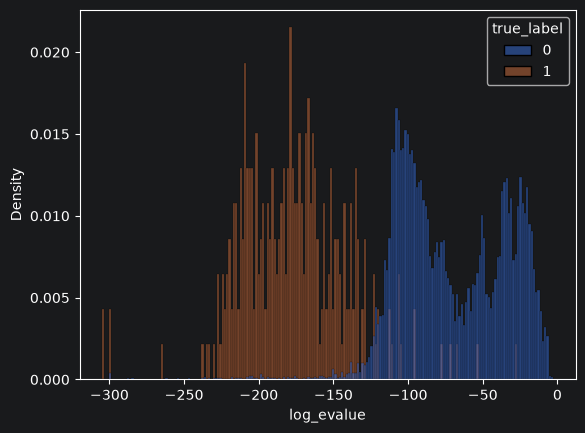

In [214]:
hmm_results_df['log_evalue'] = np.log10(hmm_results_df['evalue'].replace(0, 1e-300))

sns.histplot(data=hmm_results_df, x='log_evalue', hue='true_label', bins=200, stat='density', common_norm=False)
hmm_results_df.groupby('true_label')['evalue'].describe()

In [219]:
# Fill missing evalue (no hit) with a very large number before taking log
hmm_results_df['evalue_filled'] = hmm_results_df['evalue'].fillna(1e10)  # arbitrarily "very insignificant"
hmm_results_df['log_evalue'] = np.log10(hmm_results_df['evalue_filled'].replace(0, 1e-300))

# Higher score = more confident, so flip sign of log_evalue (since lower evalue = more confident)
y_true = hmm_results_df['true_label']
y_score = -hmm_results_df['log_evalue']  # negate so higher = more confident

precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)

# F1 at each threshold (thresholds has len = len(precisions) - 1)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
hmm_results_df['pred_label'] = hmm_results_df['log_evalue'] < -best_threshold

print(f"Best threshold on -log_evalue: {best_threshold}")

Best threshold on -log_evalue: 142.30613608192613


In [229]:
hmm_fold_results = pd.DataFrame([{
    'species': s.split('_')[0],
    'precision': precision_score(d['true_label'], d['pred_label']),
    'recall': recall_score(d['true_label'], d['pred_label']),
    'accuracy': accuracy_score(d['true_label'], d['pred_label'])
} for s, d in hmm_results_df.groupby('species')])
hmm_fold_results

,species,precision,recall,accuracy
0,Athaliana,0.631579,0.923077,0.992118
1,Fvesca,0.294118,0.500000,0.981602
2,Gmax,0.966667,0.763158,0.990884
3,Osativa,0.857143,0.823529,0.988842
4,Pvulgaris,0.953846,0.911765,0.992611
5,Slycopersicum,0.291667,0.823529,0.961378
6,Vvinifera,0.670000,0.917808,0.966116


## [ESM] Build dataset

In [163]:
LOAD_ESM = True  #@param {type:"boolean"}

### Load ESM model

In [164]:
esm_model, alphabet = esm.pretrained.esm2_t30_150M_UR50D()
batch_converter = alphabet.get_batch_converter()
esm_model.eval()

device = torch.device(
    'mps' if torch.backends.mps.is_available()
    else 'cuda' if torch.cuda.is_available()
    else 'cpu'
)
esm_model = esm_model.to(device)

### Generate or load embeddings

In [165]:
def esm_embed_records(records, esm_model, alphabet, batch_converter, device,
                           batch_size=8, max_len=1022):
    esm_model.eval()
    embeddings = {}

    print(f"Using device: {device}")

    # ESM has a length limit; truncate very long sequences
    data = [(rec.id, str(rec.seq)[:max_len]) for rec in records]
    data = sorted(data, key=lambda x: len(x[1]))

    for i in tqdm(range(0, len(data), batch_size), desc="Embedding batches"):
        batch = data[i:i+batch_size]
        labels, strs, tokens = batch_converter(batch)
        tokens = tokens.to(device)

        with torch.no_grad():
            out = esm_model(tokens, repr_layers=[esm_model.num_layers])
            reps = out['representations'][esm_model.num_layers]  # (batch, seq_len, embed_dim)

        for j, (label, seq) in enumerate(batch):
            # mean-pool over real residues, skipping BOS/EOS/padding tokens
            seq_len = len(seq)
            emb = reps[j, 1:seq_len+1].mean(0)  # +1 to skip BOS token
            embeddings[label] = emb.cpu().numpy()

    return embeddings

ESM_MODEL_NAME = 'esm2_t30_150M_UR50D'
ESM_SAVE_PATH = Path(f'../saves/{ESM_MODEL_NAME}_embeddings.npz')

def save_embeddings(embeddings: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    ids = np.array(list(embeddings.keys()))
    vecs = np.stack([embeddings[i] for i in ids])
    np.savez_compressed(path, ids=ids, embeddings=vecs)
    print(f'Saved {len(ids)} embeddings to {path}')

def load_embeddings(path: Path) -> dict:
    data = np.load(path, allow_pickle=False)
    ids, vecs = data['ids'], data['embeddings']
    return {i: v for i, v in zip(ids, vecs)}

all_ids = set(rec.id for rec in records)

if LOAD_ESM and ESM_SAVE_PATH.exists():
    embeddings_full_esm = load_embeddings(ESM_SAVE_PATH)
    missing_ids = all_ids - set(embeddings_full_esm.keys())

    if missing_ids:
        print(f'{len(missing_ids)} records missing from saved embeddings, generating those')
        missing_records = [rec for rec in records if rec.id in missing_ids]
        new_embeddings = esm_embed_records(missing_records, esm_model, alphabet, batch_converter, device)
        embeddings_full_esm.update(new_embeddings)
        save_embeddings(embeddings_full_esm, ESM_SAVE_PATH)  # persist the merged set
    else:
        print(f'Loaded {len(embeddings_full_esm)} embeddings from {ESM_SAVE_PATH}, all records covered')
else:
    embeddings_full_esm = esm_embed_records(records, esm_model, alphabet, batch_converter, device)
    save_embeddings(embeddings_full_esm, ESM_SAVE_PATH)

X_deduped_esm = pd.DataFrame(
    [embeddings_full_esm[rec.id] for rec in records_deduped],
    index=[rec.id for rec in records_deduped]
)
print(X_deduped_esm.shape)

Loaded 9407 embeddings from ../saves/esm2_t30_150M_UR50D_embeddings.npz, all records covered
(8894, 640)


### Keep embeddings for full data

In [166]:
# Save copy of full ESM feature matrix
X_esm = pd.DataFrame(
    [embeddings_full_esm[rec.id] for rec in records],
    index=[rec.id for rec in records]
)

y = np.array([labels[rec.id] for rec in records])
groups = np.array([record_species[rec.id] for rec in records])

print(X_esm.shape, 'full post-kinase-filter pre-dedup ESM dataset')

(8945, 640) full post-kinase-filter pre-dedup ESM dataset


## [k-mer] Build dataset

### Build k-mer vectors

In [167]:
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY'
K = 2

all_kmers = [''.join(p) for p in itertools.product(AMINO_ACIDS, repeat=K)]
kmer_index = {kmer: i for i, kmer in enumerate(all_kmers)}
print(f'{len(all_kmers)} possible {K}-mers')

def kmer_freq_vector(seq, k, kmer_index):
    seq = str(seq).upper()
    vec = np.zeros(len(kmer_index))
    count = 0
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if kmer in kmer_index:  # skip ambiguous
            vec[kmer_index[kmer]] += 1
            count += 1
    if count > 0:
        vec /= count  # normalize
    return vec

X_deduped_kmer = pd.DataFrame(
    [kmer_freq_vector(rec.seq, K, kmer_index) for rec in records_deduped],
    columns=all_kmers,
    index=[rec.id for rec in records_deduped]
)
print(X_deduped_kmer.shape)
display(X_deduped_kmer.head())

400 possible 2-mers
(8894, 400)


,AA,AC,AD,AE,AF,AG,AH,AI,AK,AL,...,YM,YN,YP,YQ,YR,YS,YT,YV,YW,YY
PRAM_24043.1.p1,0.001820,0.000910,0.000000,0.001820,0.000910,0.000000,0.000910,0.002730,0.000910,0.010919,...,0.000910,0.00182,0.000910,0.000000,0.000000,0.001820,0.000000,0.000910,0.0,0.000910
PRAM_25906.1.p1,0.007072,0.000000,0.000000,0.002829,0.000000,0.002829,0.000000,0.004243,0.007072,0.002829,...,0.001414,0.00000,0.002829,0.000000,0.002829,0.002829,0.002829,0.001414,0.0,0.001414
PRAM_26245.1.p1,0.003049,0.000000,0.000000,0.000000,0.001524,0.003049,0.000000,0.006098,0.000000,0.003049,...,0.000000,0.00000,0.001524,0.003049,0.001524,0.006098,0.001524,0.003049,0.0,0.000000
PRAM_26268.1.p1,0.004890,0.000000,0.000000,0.004890,0.002445,0.002445,0.002445,0.004890,0.007335,0.007335,...,0.002445,0.00000,0.000000,0.002445,0.004890,0.004890,0.007335,0.002445,0.0,0.002445
PRAM_26328.1.p1,0.006126,0.001531,0.003063,0.003063,0.003063,0.003063,0.000000,0.003063,0.003063,0.006126,...,0.001531,0.00000,0.001531,0.001531,0.001531,0.003063,0.001531,0.003063,0.0,0.000000


### Build k-mer vectors for full data

This is needed for some analysis requiring un-deduped data.

In [168]:
X_kmer = pd.DataFrame(
    [kmer_freq_vector(rec.seq, K, kmer_index) for rec in records],
    columns=all_kmers,
    index=[rec.id for rec in records]
)
y = np.array([labels[rec.id] for rec in records])
groups = np.array([record_species[rec.id] for rec in records])

print(X_kmer.shape, 'full post-kinase-filter pre-dedup dataset')

(8945, 400) full post-kinase-filter pre-dedup dataset


## Check dataset

In [169]:
zero_rows = (X_deduped_kmer.sum(axis=1) == 0).sum()
print(f'{zero_rows} sequences with no valid k-mers extracted')

print(len(groups), 'group labels built')
print(len(set(groups)), 'unique species in groups')

pos_species = pd.Series([record_species[rec.id] for rec in records_deduped if labels_deduped[rec.id] == 1])
print(pos_species.value_counts())

0 sequences with no valid k-mers extracted
8945 group labels built
7 unique species in groups
Gmax_189_protein_primaryTranscriptOnly                     76
Vvinifera_457_v2.1.protein_primaryTranscriptOnly           73
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly           68
Osativa_204_v7.0.protein_primaryTranscriptOnly             51
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly    17
Athaliana_447_Araport11.protein_primaryTranscriptOnly      13
Fvesca_226_v1.1.protein_primaryTranscriptOnly              10
Name: count, dtype: int64


## Positive-unlabeled bagging

https://academic.oup.com/bib/article/23/1/bbab461/6415313

Should be ran per LOGO fold to avoid data leak but it takes too long, could do a one-fold test occcasionally instead.

In [170]:
RUN_PU = True  #@param {type: "boolean"}

### PU global diagnostic

In [171]:
if RUN_PU:
    N_ITER = 100
    NEG_SAMPLE_RATIO = 3

    pos_idx_all = np.where(y_deduped == 1)[0]
    neg_idx_all = np.where(y_deduped == 0)[0]

    pu_scores_diag, n_oob_diag = run_pu_bagging(
        X_deduped_kmer, y_deduped, pos_idx_all, neg_idx_all,
        n_iter=N_ITER, neg_sample_ratio=NEG_SAMPLE_RATIO, seed=2026,
    )

    pu_df_diagnostic = pd.DataFrame({
        'id': X_deduped_kmer.index[neg_idx_all],
        'species': groups_deduped[neg_idx_all],
        'pu_score': pu_scores_diag,
        'n_oob': n_oob_diag,
    }).sort_values('pu_score', ascending=False)
    display(pu_df_diagnostic.groupby('species').head())

,id,species,pu_score,n_oob
823,Solyc11T000233.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.968773,89.0
822,Solyc11T000232.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.966601,90.0
14,Solyc01T000275.1,Slycopersicum_796_ITAG5.0.protein_primaryTrans...,0.912118,90.0
2098,VIT_201s0011g03980.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.887079,90.0
2179,VIT_216s0013g01386.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.875791,94.0
2456,VIT_200s0294g00080.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.874445,92.0
2104,VIT_201s0026g01420.1,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.867774,92.0
2293,VIT_218s0001g11620.2,Vvinifera_457_v2.1.protein_primaryTranscriptOnly,0.804209,89.0
3809,mrna20632.1-v1.0-hybrid,Fvesca_226_v1.1.protein_primaryTranscriptOnly,0.792055,88.0
7091,Glyma04g13054.1,Gmax_189_protein_primaryTranscriptOnly,0.786718,88.0


### PU score distribution

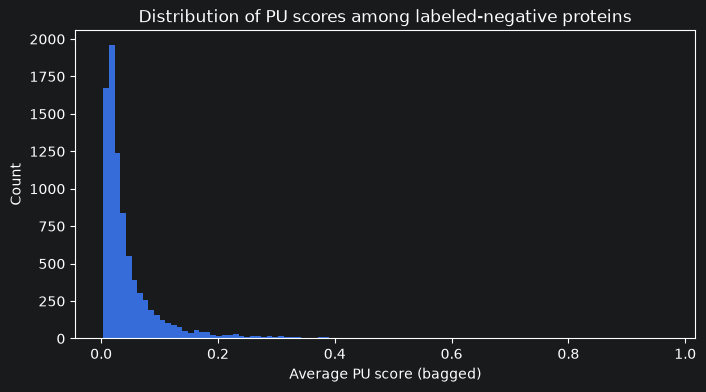

,count,mean,std,min,25%,50%,75%,max
species,,,,,,,,
Athaliana_447_Araport11.protein_primaryTranscriptOnly,1002.0,0.043418,0.065814,0.004942,0.013659,0.023626,0.046744,0.731579
Fvesca_226_v1.1.protein_primaryTranscriptOnly,914.0,0.053498,0.080294,0.004331,0.014811,0.026826,0.054284,0.792055
Gmax_189_protein_primaryTranscriptOnly,2118.0,0.052770,0.070995,0.004873,0.016550,0.029572,0.058495,0.786718
Osativa_204_v7.0.protein_primaryTranscriptOnly,1383.0,0.053009,0.079765,0.004373,0.014565,0.026630,0.054459,0.689875
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,1150.0,0.056626,0.079601,0.004253,0.016709,0.028936,0.058632,0.729919
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,941.0,0.051782,0.090206,0.004651,0.015148,0.026055,0.053533,0.968773
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,1078.0,0.066620,0.115186,0.003743,0.015994,0.030132,0.063143,0.887079


In [172]:
if RUN_PU:
    plt.figure(figsize=(8, 4))
    plt.hist(pu_df_diagnostic['pu_score'], bins=100)
    plt.xlabel('Average PU score (bagged)')
    plt.ylabel('Count')
    plt.title('Distribution of PU scores among labeled-negative proteins')
    plt.show()

    display(pu_df_diagnostic.groupby('species')['pu_score'].describe())

### Do HMM FPs match PU-flagged candidates?

Ensure this is updated to match HMM results.

In [173]:
if RUN_PU:
    pu_candidates = set(pu_df_diagnostic.loc[pu_df_diagnostic['pu_score'] >= 0.80, 'id'])

    hmm_false_positive_ids = set("""
LOC_Os01g26210.1
LOC_Os02g42110.1
LOC_Os02g42160.1
LOC_Os02g42190.1
LOC_Os04g03830.1
LOC_Os04g29580.1
LOC_Os10g09620.1
VIT_200s0294g00020.1
VIT_200s0294g00080.1
VIT_200s0424g00020.1
VIT_201s0011g03960.1
VIT_201s0011g03980.1
VIT_201s0026g01420.1
VIT_208s0007g00960.1
VIT_208s0007g04350.1
VIT_213s0019g02300.1
VIT_214s0006g02600.2
VIT_216s0013g01198.1
VIT_216s0013g01235.1
VIT_216s0013g01386.1
VIT_217s0000g03340.1
Solyc01T000275.1
Solyc05T000170.1
Solyc11T000232.1
Solyc11T000233.1
Glyma04g13054.1
Glyma18g53186.1
mrna02191.1-v1.0-hybrid
mrna11412.1-v1.0-hybrid
Phvul.001G076300.1.p
Phvul.007G031300.1.p
    """.strip().split('\n'))
    overlap = pu_candidates & hmm_false_positive_ids
    print(f'{len(overlap)} of {len(pu_candidates)} PU candidates overlap with HMM false positives')
    print(overlap)

7 of 8 PU candidates overlap with HMM false positives
{'VIT_200s0294g00080.1', 'Solyc01T000275.1', 'Solyc11T000233.1', 'Solyc11T000232.1', 'VIT_216s0013g01386.1', 'VIT_201s0026g01420.1', 'VIT_201s0011g03980.1'}


## [XGB] Model

### Positive scale weight

In [174]:
n_pos = (y_deduped == 1).sum()
n_neg = (y_deduped == 0).sum()
print(f'{n_pos} positive, {n_neg} negative')
print(f"Positive rate: {n_pos / len(labels_deduped):.3%}")

308 positive, 8586 negative
Positive rate: 3.463%


### XGBoost model

In [175]:
def make_model(scale_pos_weight, random_state=2026):
    return XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric=['aucpr'],

        n_estimators=1200,
        max_depth=3,
        learning_rate=0.05,
        min_child_weight=6,
        gamma=0,

        random_state=random_state,
        n_jobs=-1,
    )

class XGBEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        scale_pos_weight = get_scale_pos_weight(y_train)
        return make_model(scale_pos_weight)

    def fit_model_per_split(self, model, X_train, y_train, X_val, y_val):
        model.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False,
        )
        return model

    def extra_metrics_per_split(self, model, X_train, y_train, X_val, y_val):
        evals = model.evals_result()
        val_curve = evals['validation_1']['aucpr']
        best_round = int(np.argmax(val_curve))
        return {
            'best_round': best_round,
            'best_val_pr_auc': val_curve[best_round],
            'final_val_pr_auc': val_curve[-1],
            'n_flagged': getattr(self, '_last_n_flagged', None),
        }

    def extra_artifacts_per_split(self, model, X_train, y_train, X_val, y_val,
                                   X_val_full, y_val_full, preds_full):
        artifacts = {
            'evals': model.evals_result(),
            'importance': pd.Series(
                model.feature_importances_, index=X_train.columns
            ).sort_values(ascending=False),
        }
        return artifacts

### Fit

In [176]:
# Fit XGBoost with k-mer
xgb_evaluator = XGBEvaluator(
    logo=logo,
    X=X_deduped_kmer,
    y=y_deduped,
    groups=groups_deduped,
    threshold=0.35,
    X_full=X_kmer,
    y_full=y,
    groups_full=groups,
    run_pu=RUN_PU
)
xgb_evaluator.fit()

xgb_evaluator.results_df

Evaluating: 100%|██████████| 7/7 [02:55<00:00, 25.14s/it, Vvinifera]    


,species,baseline,lift,train_pr_auc,val_pr_auc,gap,log_loss_gap,train_precision,val_precision,train_recall,...,val_accuracy,train_bias,val_bias,n_pos,found,false_positives,best_round,best_val_pr_auc,final_val_pr_auc,n_flagged
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,0.012808,63.951932,1.0,0.819089,0.180911,0.019419,1.0,0.75,1.0,...,0.993103,0.000826,-0.000831,13,9,3,389,0.832809,0.81524,10
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,0.010823,70.005817,1.0,0.757639,0.242361,0.020302,1.0,0.7,1.0,...,0.993506,0.000845,-0.000964,10,7,3,1194,0.753881,0.75387,7
Gmax_189_protein_primaryTranscriptOnly,Gmax,0.03464,27.494372,1.0,0.952403,0.047597,0.024447,1.0,0.939394,1.0,...,0.991796,0.000878,-0.004168,90,74,4,1163,0.952266,0.95212,7
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,0.035565,24.928062,1.0,0.886563,0.113437,0.045155,1.0,0.880952,1.0,...,0.98675,0.000836,-0.007762,52,38,5,371,0.891247,0.88592,7
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,0.055829,17.472711,1.0,0.975488,0.024512,0.022081,1.0,0.955882,1.0,...,0.995074,0.000806,0.00001,73,70,3,203,0.977806,0.975434,8
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,0.017745,40.37231,1.0,0.716419,0.283581,0.048279,1.0,0.578947,1.0,...,0.985386,0.000825,0.002618,17,11,8,1128,0.707844,0.707844,7
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,0.063423,14.015904,1.0,0.888932,0.111068,0.05047,1.0,0.813953,1.0,...,0.983493,0.000817,0.005872,104,100,16,182,0.913067,0.886499,5


In [177]:
precision = xgb_evaluator.results_df['val_precision']
recall = xgb_evaluator.results_df['val_recall']

print("XGB model")
print(f"Precision: {precision.mean():.3f}±{precision.std():.3f}")
print(f"Recall:    {recall.mean():.3f}±{recall.std():.3f}")

XGB model
Precision: 0.803±0.136
Recall:    0.785±0.128


### Learning curves

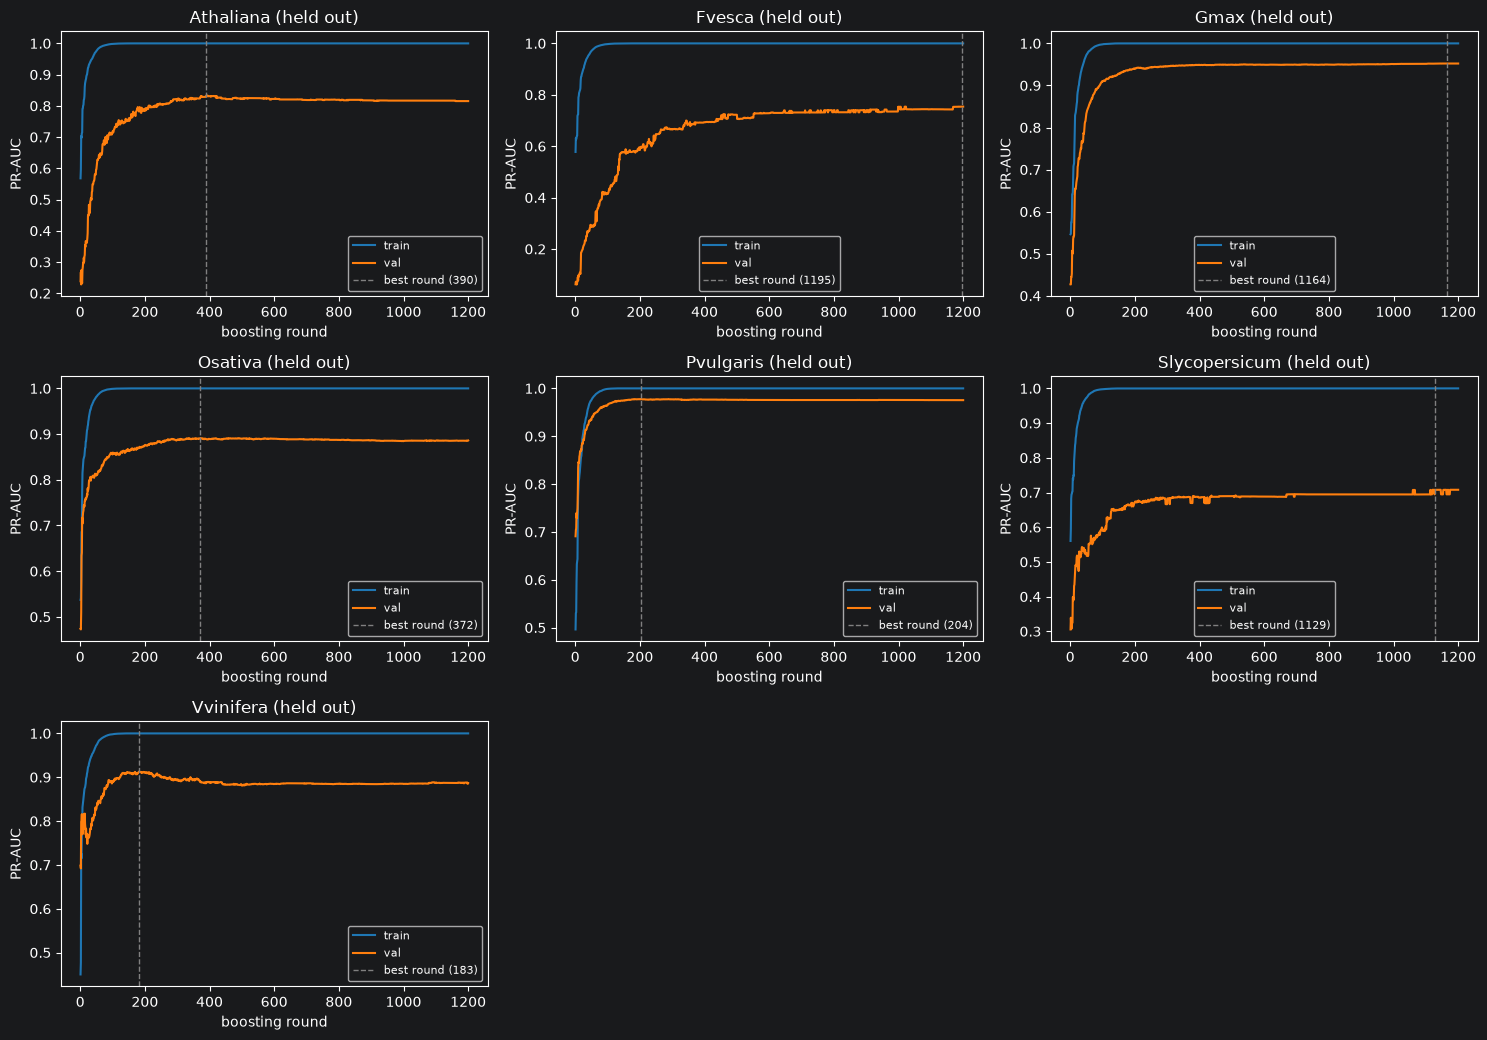

In [178]:
species_list = list(xgb_evaluator.fold_artifacts.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    evals = xgb_evaluator.fold_artifacts[species]['evals']
    train_curve = evals['validation_0']['aucpr']
    val_curve = evals['validation_1']['aucpr']
    rounds = range(1, len(train_curve) + 1)

    ax.plot(rounds, train_curve, label='train', color='tab:blue')
    ax.plot(rounds, val_curve, label='val', color='tab:orange')
    best_round = int(xgb_evaluator.fold_results[species]['best_round']) + 1
    ax.axvline(best_round, color='gray', linestyle='--', linewidth=1, label=f'best round ({best_round})')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('boosting round')
    ax.set_ylabel('PR-AUC')
    ax.legend(fontsize=8)

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall graphs

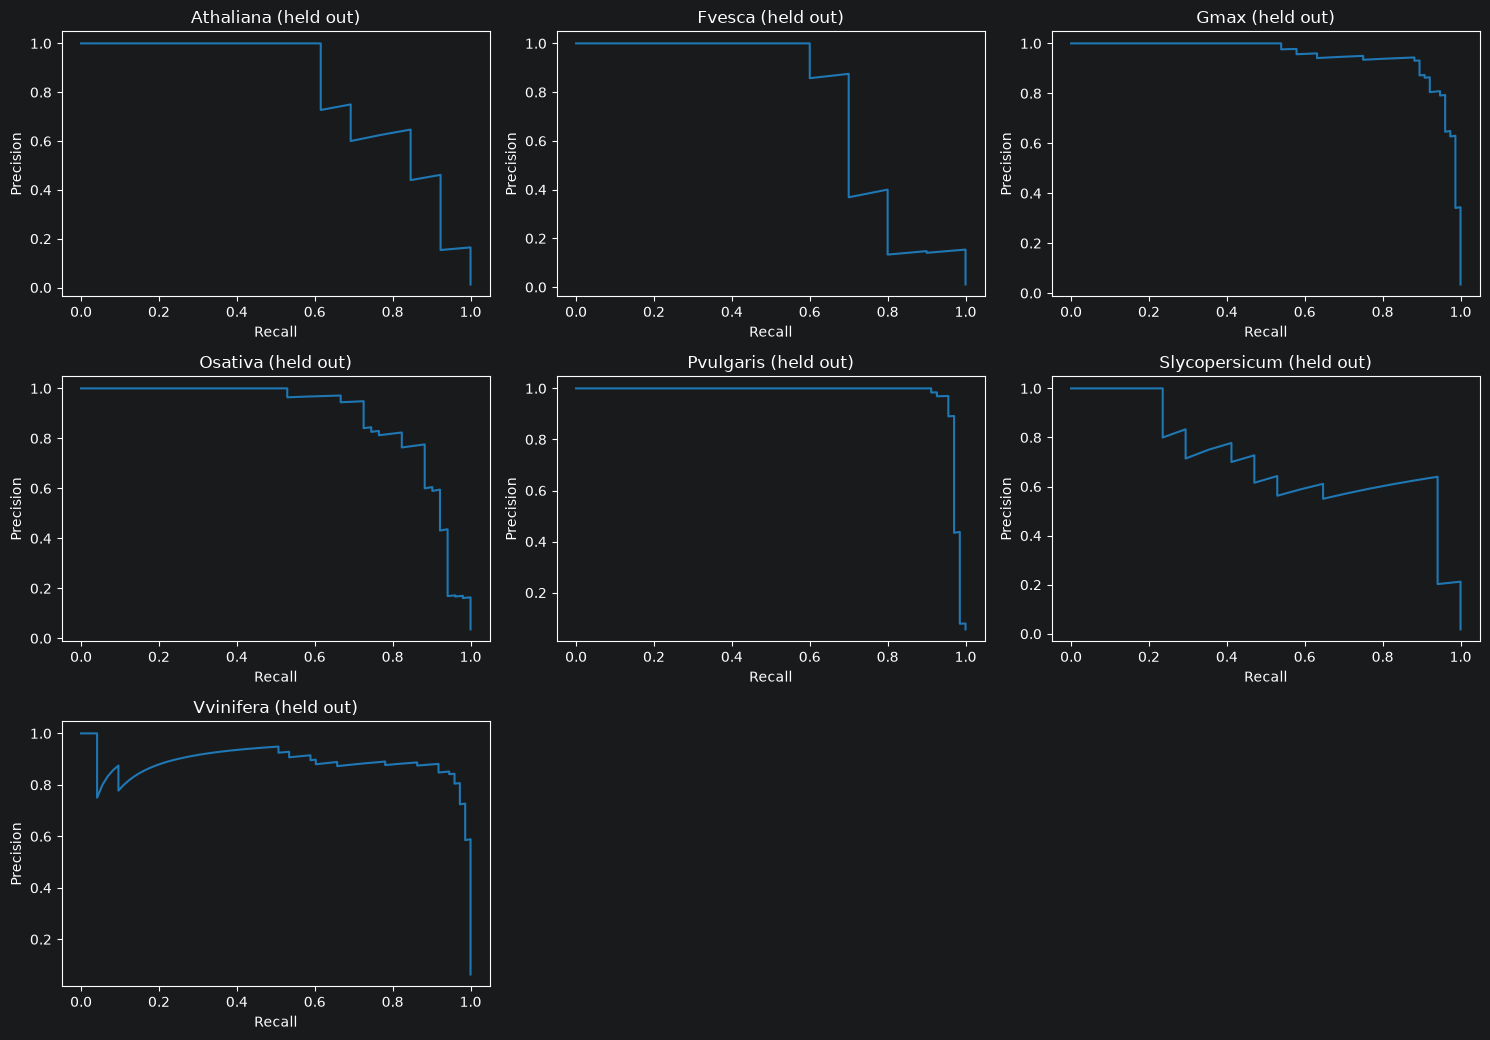

In [179]:
species_list = list(xgb_evaluator.fold_preds.keys())
n = len(species_list)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

for i, species in enumerate(species_list):
    ax = axes[i // ncols][i % ncols]
    data = xgb_evaluator.fold_preds[species]
    precisions, recalls, thresholds = precision_recall_curve(data['y_true'], data['preds'])

    ax.plot(recalls, precisions, color='tab:blue')
    ax.set_title(f'{species.split("_")[0]} (held out)')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')

for j in range(n, nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()

### Precision-recall aggregated

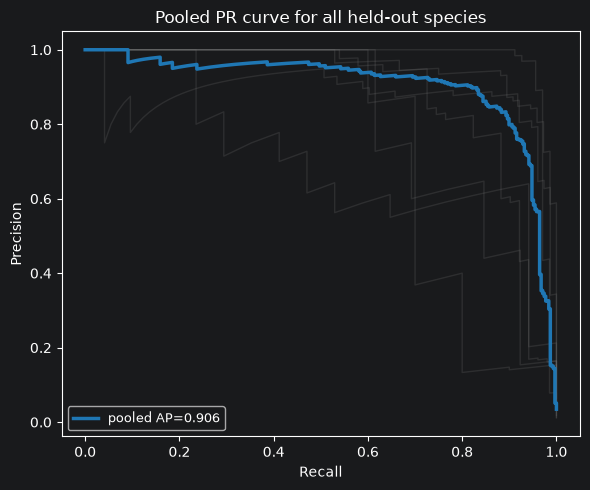

In [180]:
all_y_true = np.concatenate([xgb_evaluator.fold_preds[s]['y_true'] for s in xgb_evaluator.fold_preds])
all_preds = np.concatenate([xgb_evaluator.fold_preds[s]['preds'] for s in xgb_evaluator.fold_preds])

precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(all_y_true, all_preds)
pr_auc = average_precision_score(all_y_true, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in xgb_evaluator.fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

# for i, t in enumerate(thresholds_xgb):
#     if i % 5 == 0 and t > 0.05 and t < 0.95:
#         print(f'thresh={t:.2f} -> R={recalls_xgb[i]:.3f} P={precisions_xgb[i]:.3f} ')

ax.plot(recalls_xgb, precisions_xgb, color='tab:blue', linewidth=2.5, label=f'pooled AP={pr_auc:.3f}')

ax.set_title('Pooled PR curve for all held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Recall at FP budgets

In [181]:
def recall_at_fp_budgets(y_true, preds, fp_budgets):
    order = np.argsort(-preds)
    y_sorted = y_true[order]

    n_pos = y_sorted.sum()
    cum_tp = np.cumsum(y_sorted == 1)
    cum_fp = np.cumsum(y_sorted == 0)

    results = {}
    for budget in fp_budgets:
        eligible = np.where(cum_fp <= budget)[0]
        if len(eligible) == 0:
            results[budget] = {'found': 0, 'recall': 0.0, 'actual_fp': 0}
            continue
        idx = eligible[-1]
        results[budget] = {
            'found': int(cum_tp[idx]),
            'recall': cum_tp[idx] / n_pos,
            'actual_fp': int(cum_fp[idx]),
        }
    return results

fp_budgets = [5, 10, 15]

recall_rows = {}
for species, data in xgb_evaluator.fold_preds.items():
    per_budget = recall_at_fp_budgets(data['y_true'], data['preds'], fp_budgets)
    for budget, stats in per_budget.items():
        recall_rows[(species.split('_')[0], budget)] = stats

recall_df = pd.DataFrame(recall_rows).T
recall_df.index.names = ['species', 'fp_budget']
recall_df

found    recall  actual_fp
species       fp_budget                            
Athaliana     5            9.0  0.692308        5.0
              10          11.0  0.846154       10.0
              15          12.0  0.923077       15.0
Fvesca        5            7.0  0.700000        5.0
              10           7.0  0.700000       10.0
              15           8.0  0.800000       15.0
Gmax          5           68.0  0.894737        5.0
              10          69.0  0.907895       10.0
              15          70.0  0.921053       15.0
Osativa       5           37.0  0.725490        5.0
              10          42.0  0.823529       10.0
              15          45.0  0.882353       15.0
Pvulgaris     5           65.0  0.955882        5.0
              10          66.0  0.970588       10.0
              15          66.0  0.970588       15.0
Slycopersicum 5            9.0  0.529412        5.0
              10          16.0  0.941176       10.0
              15          16.0  0.941176       15.0
Vvinifera     5           44.0  0.602740        5.0
              10          67.0  0.917808       10.0
              15          70.0  0.958904       15.0

### Species-specific split details

In [182]:
def specific_results(species_full: str):
    species_short = species_full.split('_')[0]
    df = xgb_evaluator.fold_details[species_full]

    predicted_positive = df['pred'] >= 0.5
    hits = df[(df['y_true'] == 1) & predicted_positive]
    misses = df[(df['y_true'] == 1) & ~predicted_positive]
    false_positives = df[(df['y_true'] == 0) & predicted_positive]

    print(f"\n{'='*10} {species_short} {'='*10}")
    print(f'Hits ({len(hits)}):\n{hits}')
    print(f'\nMisses ({len(misses)}):\n{misses}')
    print(f'\nFalse positives ({len(false_positives)}):\n{false_positives}')

specific_results('Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly')
specific_results('Athaliana_447_Araport11.protein_primaryTranscriptOnly')
specific_results('Osativa_204_v7.0.protein_primaryTranscriptOnly')
specific_results('Vvinifera_457_v2.1.protein_primaryTranscriptOnly')
specific_results('Gmax_189_protein_primaryTranscriptOnly')
specific_results('Fvesca_226_v1.1.protein_primaryTranscriptOnly')
specific_results('Pvulgaris_442_v2.1.protein_primaryTranscriptOnly')


========== Slycopersicum ==========
Hits (11):
                  id  y_true      pred
0   Solyc03T000226.2       1  0.999968
1   Solyc04T000158.1       1  0.999952
2   Solyc03T001769.1       1  0.999936
3   Solyc05T000401.1       1  0.999783
5    PRAM_26245.1.p1       1  0.999624
7   Solyc02T001806.1       1  0.999065
8   Solyc05T000399.1       1  0.997130
10  Solyc02T002539.1       1  0.967861
13  Solyc04T002734.1       1  0.922228
16  Solyc03T003214.1       1  0.597807
17  Solyc05T000396.1       1  0.564256

Misses (6):
                  id  y_true      pred
20  Solyc01T000282.1       1  0.313317
21  Solyc05T000406.1       1  0.281365
22  Solyc04T000159.1       1  0.242202
23  Solyc05T000582.1       1  0.217038
24  Solyc01T000276.1       1  0.207319
79  Solyc02T001670.1       1  0.002158

False positives (7):
                  id  y_true      pred
4   Solyc11T000233.1       0  0.999773
6   Solyc11T000232.1       0  0.999536
9   Solyc01T000275.1       0  0.994933
11  Solyc05T000170.1

### Feature importance per split

#### Importance Spearman correlation

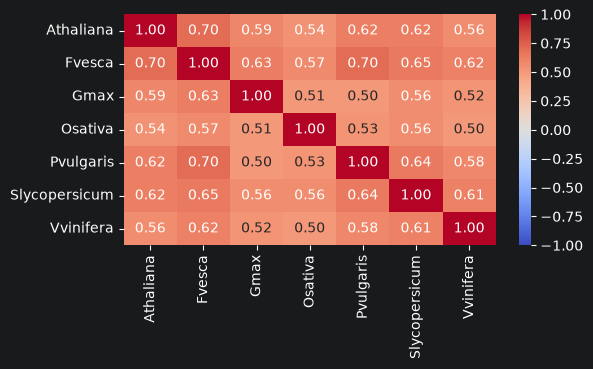

In [183]:
importance_df = pd.DataFrame({
    species.split('_')[0]: artifacts['importance']
    for species, artifacts in xgb_evaluator.fold_artifacts.items()
})

corr_matrix = importance_df.corr(method="spearman")
plt.figure(figsize=(6, 3))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.show()

#### Top features Jaccard similarity

In [184]:
def top_k_jaccard(importance_df, k=20):
    top_sets = {
        species: set(importance_df[species].sort_values(ascending=False).head(k).index)
        for species in importance_df.columns
    }

    species_list = list(top_sets.keys())
    results = {}
    for i in range(len(species_list)):
        for j in range(i+1, len(species_list)):
            a, b = species_list[i], species_list[j]
            intersection = top_sets[a] & top_sets[b]
            union = top_sets[a] | top_sets[b]
            results[(a, b)] = len(intersection) / len(union)

    return results, top_sets

jaccard_scores, top_sets = top_k_jaccard(importance_df, k=20)
for pair, score in jaccard_scores.items():
    print(f"{pair[0]} vs {pair[1]}: {score:.2f}")

common_across_all = set.intersection(*top_sets.values())
print(f"\n{len(common_across_all)} features in every fold's top-20:")
print(common_across_all)

Athaliana vs Fvesca: 0.48
Athaliana vs Gmax: 0.48
Athaliana vs Osativa: 0.43
Athaliana vs Pvulgaris: 0.54
Athaliana vs Slycopersicum: 0.48
Athaliana vs Vvinifera: 0.29
Fvesca vs Gmax: 0.33
Fvesca vs Osativa: 0.43
Fvesca vs Pvulgaris: 0.48
Fvesca vs Slycopersicum: 0.43
Fvesca vs Vvinifera: 0.33
Gmax vs Osativa: 0.38
Gmax vs Pvulgaris: 0.33
Gmax vs Slycopersicum: 0.33
Gmax vs Vvinifera: 0.25
Osativa vs Pvulgaris: 0.48
Osativa vs Slycopersicum: 0.43
Osativa vs Vvinifera: 0.25
Pvulgaris vs Slycopersicum: 0.43
Pvulgaris vs Vvinifera: 0.29
Slycopersicum vs Vvinifera: 0.29

7 features in every fold's top-20:
{'HF', 'GC', 'YH', 'CG', 'DL', 'WC', 'GF'}


## [LogReg] Model

A simpler model than XGBoost, same purpose as cosine similarity above.

### Train model

In [185]:
class LogRegEvaluator(PUFilterMixin, LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(class_weight='balanced', max_iter=1000, random_state=2026, C=0.1)
        )

    def extra_metrics_per_split(self, model, X_train, y_train, X_val, y_val):
        return {'n_flagged': getattr(self, '_last_n_flagged', None)}

# Build logistic regression with ESM-2
logreg_evaluator = LogRegEvaluator(
    logo=logo,
    X=X_deduped_esm,
    y=y_deduped,
    groups=groups_deduped,
    threshold=0.85,
    X_full=X_esm,
    y_full=y,
    groups_full=groups,
    run_pu=RUN_PU,
).fit()

logreg_evaluator.results_df

Evaluating: 100%|██████████| 7/7 [02:21<00:00, 20.16s/it, Vvinifera]    


,species,baseline,lift,train_pr_auc,val_pr_auc,gap,log_loss_gap,train_precision,val_precision,train_recall,val_recall,train_accuracy,val_accuracy,train_bias,val_bias,n_pos,found,false_positives,n_flagged
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,0.012808,68.686235,0.995651,0.879725,0.115925,0.042468,0.9699,0.571429,0.983051,0.923077,0.998217,0.990148,0.011162,0.020728,13,12,9,29
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,0.010823,83.558276,0.995553,0.90431,0.091243,0.002943,0.966997,1.0,0.983221,0.8,0.998111,0.997835,0.011529,0.00911,10,8,0,30
Gmax_189_protein_primaryTranscriptOnly,Gmax,0.03464,27.318031,0.996519,0.946295,0.050224,0.014604,0.958333,0.942029,0.991379,0.855263,0.998203,0.993163,0.010685,0.011018,90,79,4,24
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,0.035565,26.824056,0.995173,0.953994,0.041179,0.012077,0.961977,0.978261,0.984436,0.882353,0.998118,0.995119,0.011695,0.011547,52,46,1,22
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,0.055829,17.298956,0.993871,0.965787,0.028084,0.024555,0.963563,0.970149,0.991667,0.955882,0.998561,0.995895,0.010039,0.011382,73,70,2,30
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,0.017745,32.549115,0.997156,0.577594,0.419562,0.056395,0.976271,0.65,0.989691,0.764706,0.998736,0.988518,0.009941,0.01693,17,13,7,25
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,0.063423,12.776894,0.999013,0.81035,0.188663,0.087101,0.982979,0.810127,0.982979,0.876712,0.998964,0.979149,0.011095,0.024014,104,87,15,18


In [186]:
precision = logreg_evaluator.results_df['val_precision']
recall = logreg_evaluator.results_df['val_recall']

print("LogReg model")
print(f"Precision: {precision.mean():.3f}±{precision.std():.3f}")
print(f"Recall:    {recall.mean():.3f}±{recall.std():.3f}")

LogReg model
Precision: 0.846±0.174
Recall:    0.865±0.066


### Precision-recall aggregated

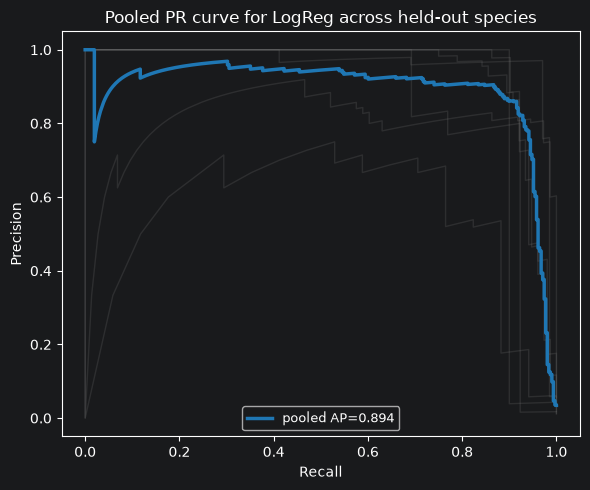

In [187]:
logreg_fold_preds = logreg_evaluator.fold_preds

all_y_true_logreg = np.concatenate([logreg_fold_preds[s]['y_true'] for s in logreg_fold_preds])
all_preds_logreg = np.concatenate([logreg_fold_preds[s]['preds'] for s in logreg_fold_preds])

precisions_logreg, recalls_logreg, thresholds_logreg = precision_recall_curve(all_y_true_logreg, all_preds_logreg)
pr_auc_logreg = average_precision_score(all_y_true_logreg, all_preds_logreg)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in logreg_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

# for i, t in enumerate(thresholds_logreg):
#     if i % 10 == 0 and t > 0.05 and t < 0.95:
#         print(f'thresh={t:.2f} -> R={recalls_logreg[i]:.3f} P={precisions_logreg[i]:.3f} ')

ax.plot(
    recalls_logreg, precisions_logreg, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_logreg:.3f}',
)

ax.set_title('Pooled PR curve for LogReg across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Cross-model analysis

### Error overlap

In [188]:
thresh = 0.5

def get_misses_fps(evaluator):
    misses = set()
    fps = set()
    for details in evaluator.fold_details.values():
        predicted_positive = details['pred'] >= thresh
        misses.update(details[(details['y_true'] == 1) & ~predicted_positive]['id'])
        fps.update(details[(details['y_true'] == 0) & predicted_positive]['id'])
    return misses, fps

xgb_misses, xgb_fps = get_misses_fps(xgb_evaluator)
lr_misses, lr_fps = get_misses_fps(logreg_evaluator)

def overlap_report(name, set_a, set_b, label_a='XGB', label_b='LogReg'):
    shared = set_a & set_b
    union = set_a | set_b
    jaccard = len(shared) / len(union) if union else float('nan')
    only_a = set_a - set_b
    only_b = set_b - set_a

    print(f"\n{'='*8} {name} {'='*8}")
    print(f"{label_a} only:  {len(only_a):>4}")
    print(f"{label_b} only:  {len(only_b):>4}")
    print(f"shared:      {len(shared):>4}  ({len(shared)/len(set_a)*100:.0f}% of {label_a}'s, "
          f"{len(shared)/len(set_b)*100:.0f}% of {label_b}'s)")
    print(f"jaccard:     {jaccard:.3f}")
    return only_a, only_b, shared

xgb_only_misses, lr_only_misses, shared_misses = overlap_report("FALSE NEGATIVES", xgb_misses, lr_misses)
xgb_only_fps, lr_only_fps, shared_fps = overlap_report("FALSE POSITIVES", xgb_fps, lr_fps)

xgb_pooled = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')['pred']
lr_pooled = pd.concat(logreg_evaluator.fold_details.values()).set_index('id')['pred']

common_ids = xgb_pooled.index.intersection(lr_pooled.index)
corr = xgb_pooled.loc[common_ids].corr(lr_pooled.loc[common_ids])
print(f"\nProbability correlation across {len(common_ids)} shared predictions: {corr:.3f}")

diffs = (xgb_pooled.loc[common_ids] - lr_pooled.loc[common_ids]).abs()
near_boundary = ((xgb_pooled.loc[common_ids] > 0.3) & (xgb_pooled.loc[common_ids] < 0.7)) | \
                ((lr_pooled.loc[common_ids] > 0.3) & (lr_pooled.loc[common_ids] < 0.7))


======== FALSE NEGATIVES ========
XGB only:    42
LogReg only:     5
shared:        14  (25% of XGB's, 74% of LogReg's)
jaccard:     0.230

======== FALSE POSITIVES ========
XGB only:     4
LogReg only:    61
shared:        25  (86% of XGB's, 29% of LogReg's)
jaccard:     0.278

Probability correlation across 8945 shared predictions: 0.893


### Confidence distributions

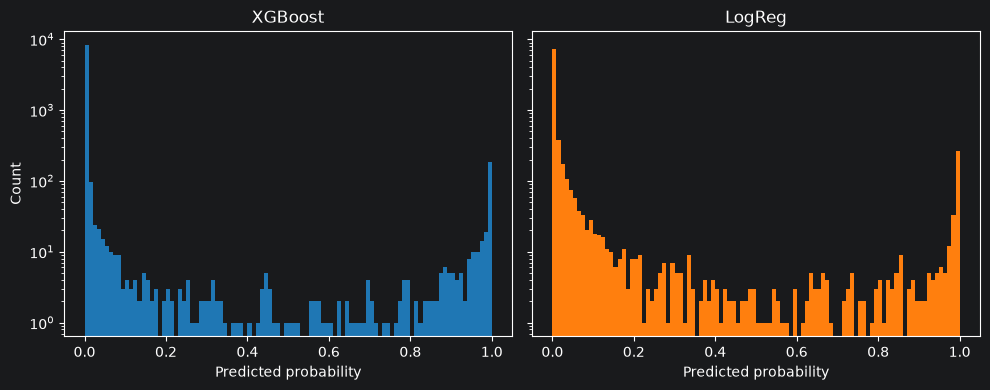

In [189]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

axes[0].hist(xgb_pooled, bins=100, color='tab:blue')
axes[0].set_title('XGBoost')
axes[0].set_xlabel('Predicted probability')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

axes[1].hist(lr_pooled, bins=100, color='tab:orange')
axes[1].set_title('LogReg')
axes[1].set_xlabel('Predicted probability')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## Meta-model

Combine k-mer XGB and ESM LogReg

### Make meta dataset

In [190]:
xgb_all = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
lr_all = pd.concat(logreg_evaluator.fold_details.values()).set_index('id')

meta_df = pd.DataFrame({
    'xgb_pred': xgb_all['pred'],
    'lr_pred': lr_all['pred'],
    'y_true': xgb_all['y_true'],
}).dropna()

assert (meta_df['y_true'] == lr_all.loc[meta_df.index, 'y_true']).all(), 'label mismatch between models'

meta_df['diff'] = meta_df['xgb_pred'] - meta_df['lr_pred']
meta_df['abs_diff'] = meta_df['diff'].abs()
meta_df['mean_pred'] = (meta_df['xgb_pred'] + meta_df['lr_pred']) / 2

meta_df['xgb_logit'] = np.log(meta_df['xgb_pred'] / (1 - meta_df['xgb_pred']))
meta_df['lr_logit'] = np.log(meta_df['lr_pred'] / (1 - meta_df['lr_pred']))

species_lookup = pd.Series(groups, index=X_kmer.index, name='species')
meta_df['species'] = species_lookup.reindex(meta_df.index)

assert meta_df['species'].notna().all(), "some ids couldn't be matched to a species"

X_meta = meta_df[['xgb_logit', 'lr_logit']]
y_meta = meta_df['y_true'].values
groups_meta = meta_df['species'].values

X_meta.head()

,xgb_logit,lr_logit
id,,
AT1G01140.3,-11.648523,-14.117577
AT1G01450.1,-6.774399,-4.993372
AT1G01540.2,-9.765367,-7.184211
AT1G01560.2,-7.288139,-7.143472
AT1G01740.2,-10.547182,-11.379283


### Fit

In [191]:
class MetaEvaluator(LOGOEvaluator):
    def make_model_per_split(self, X_train, y_train):
        return LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=2026,
            C=0.1,
        )

meta_evaluator = MetaEvaluator(
    logo=logo,
    X=X_meta,
    y=y_meta,
    groups=groups_meta,
    threshold=0.95,
)
meta_evaluator.fit()
meta_evaluator.results_df

Evaluating: 100%|██████████| 7/7 [00:00<00:00, 61.60it/s, Vvinifera]


,species,baseline,lift,train_pr_auc,val_pr_auc,gap,log_loss_gap,train_precision,val_precision,train_recall,val_recall,train_accuracy,val_accuracy,train_bias,val_bias,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,0.012808,68.957615,0.944073,0.883201,0.060872,-0.003066,0.921283,0.75,0.913295,0.923077,0.992812,0.995074,0.034423,0.034473,13,12,4
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,0.010823,79.74,0.943213,0.862987,0.080226,-0.020308,0.913793,1.0,0.911175,0.7,0.992395,0.996753,0.035042,0.031039,10,7,0
Gmax_189_protein_primaryTranscriptOnly,Gmax,0.040761,23.914775,0.925529,0.974787,-0.049258,-0.017134,0.904412,0.961039,0.914498,0.822222,0.992727,0.991395,0.039585,0.037309,90,74,3
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,0.036237,25.948977,0.941617,0.940311,0.001305,-0.014806,0.902597,1.0,0.905537,0.807692,0.992144,0.993031,0.033866,0.027819,52,42,0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,0.059689,16.413227,0.926497,0.979694,-0.053197,-0.007544,0.896194,0.972603,0.905594,0.972603,0.992618,0.996729,0.03672,0.034791,73,71,2
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,0.017745,39.003942,0.957293,0.692137,0.265157,0.018566,0.928358,0.666667,0.909357,0.823529,0.993114,0.989562,0.03482,0.031102,17,14,7
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,0.087986,10.662568,0.938958,0.938162,0.000797,0.073694,0.927126,0.864407,0.898039,0.980769,0.994332,0.984772,0.043767,0.066168,104,102,16


In [192]:
meta_evaluator.results_df[['species', 'n_pos', 'found', 'false_positives']]

,species,n_pos,found,false_positives
Athaliana_447_Araport11.protein_primaryTranscriptOnly,Athaliana,13,12,4
Fvesca_226_v1.1.protein_primaryTranscriptOnly,Fvesca,10,7,0
Gmax_189_protein_primaryTranscriptOnly,Gmax,90,74,3
Osativa_204_v7.0.protein_primaryTranscriptOnly,Osativa,52,42,0
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly,Pvulgaris,73,71,2
Slycopersicum_796_ITAG5.0.protein_primaryTranscriptOnly,Slycopersicum,17,14,7
Vvinifera_457_v2.1.protein_primaryTranscriptOnly,Vvinifera,104,102,16


### Pooled PR curve

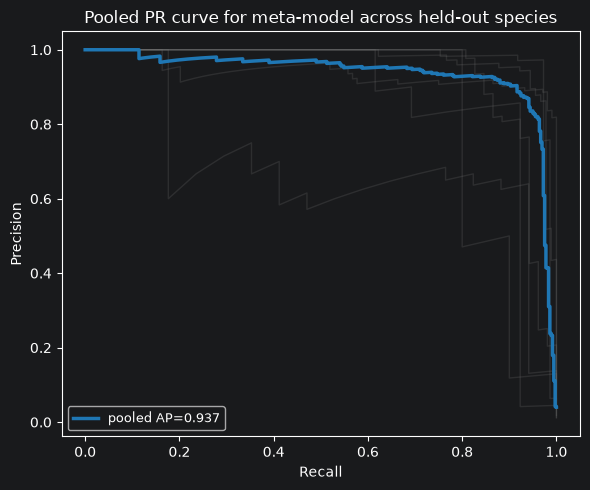

In [193]:
meta_fold_preds = meta_evaluator.fold_preds

all_y_true_meta = np.concatenate([meta_fold_preds[s]['y_true'] for s in meta_fold_preds])
all_preds_meta = np.concatenate([meta_fold_preds[s]['preds'] for s in meta_fold_preds])

precisions_meta, recalls_meta, thresholds_meta = precision_recall_curve(all_y_true_meta, all_preds_meta)
pr_auc_meta = average_precision_score(all_y_true_meta, all_preds_meta)

fig, ax = plt.subplots(figsize=(6, 5))

for species, data in meta_fold_preds.items():
    p, r, _ = precision_recall_curve(data['y_true'], data['preds'])
    ax.plot(r, p, color='gray', alpha=0.2, linewidth=1)

# for i, t in enumerate(thresholds_meta):
#     if i % 5 == 0:
#         print(f'thresh={t:.2f} -> R={recalls_meta[i]:.3f} P={precisions_meta[i]:.3f} ')

ax.plot(
    recalls_meta, precisions_meta, color='tab:blue', linewidth=2.5,
    label=f'pooled AP={pr_auc_meta:.3f}',
)

ax.set_title('Pooled PR curve for meta-model across held-out species')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Model comaprison

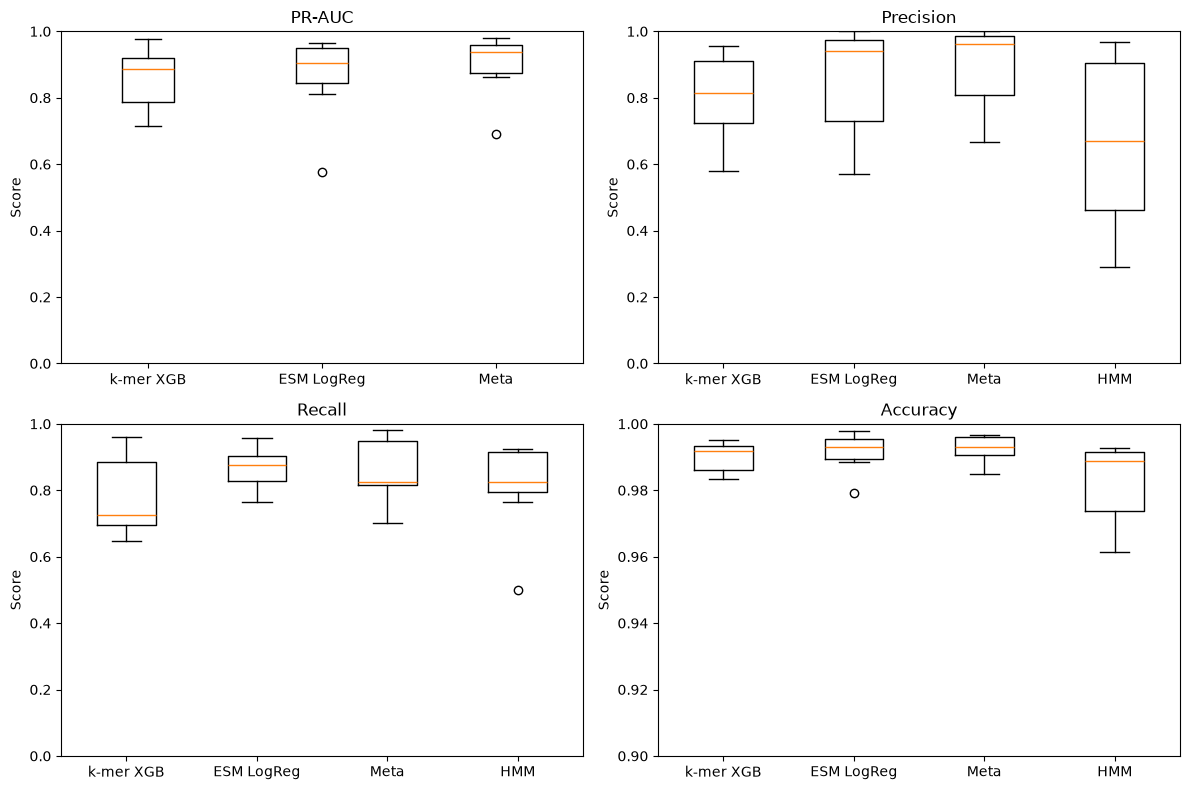

In [241]:
models = {
    'k-mer XGB': xgb_evaluator,
    'ESM LogReg': logreg_evaluator,
    'Meta': meta_evaluator,
}
model_labels = list(models)

precision = np.array([
    [result['val_precision'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['precision']])
recall = np.array([
    [result['val_recall'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['recall']])
accuracy = np.array([
    [result['val_accuracy'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
] + [hmm_fold_results['accuracy']])
pr_auc = np.array([
    [result['val_pr_auc'] for result in evaluator.fold_results.values()]
    for evaluator in models.values()
])

metrics = {
    'PR-AUC': (pr_auc, model_labels),
    'Precision': (precision, model_labels + ['HMM']),
    'Recall': (recall, model_labels + ['HMM']),
    'Accuracy': (accuracy, model_labels + ['HMM']),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (metric_name, (scores, labels)) in zip(axes.flat, metrics.items()):
    ax.boxplot(
        scores.T,
        tick_labels=labels
    )
    ax.set_title(metric_name)
    ax.set_ylabel('Score')
    if metric_name != 'Accuracy':
        ax.set_ylim(0, 1)
    else:
        ax.set_ylim(0.9, 1)

plt.tight_layout()
plt.show()

### Friedman & Nemenyi

https://www.jmlr.org/papers/volume7/demsar06a/demsar06a.pdf

Accuracy: Friedman chi2=11.057, p=0.01142


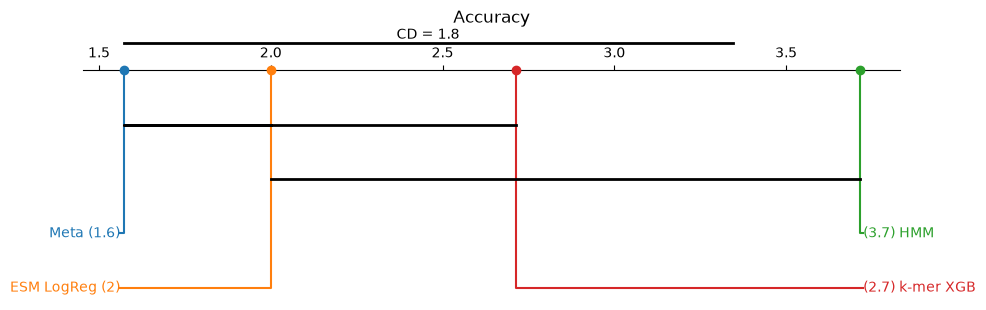

Precision: Friedman chi2=10.456, p=0.01506


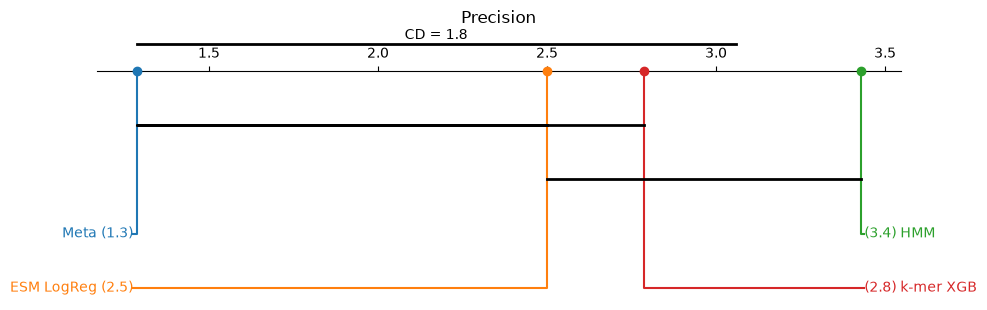

Recall: Friedman chi2=5.571, p=0.1344
Omnibus test is not significant.


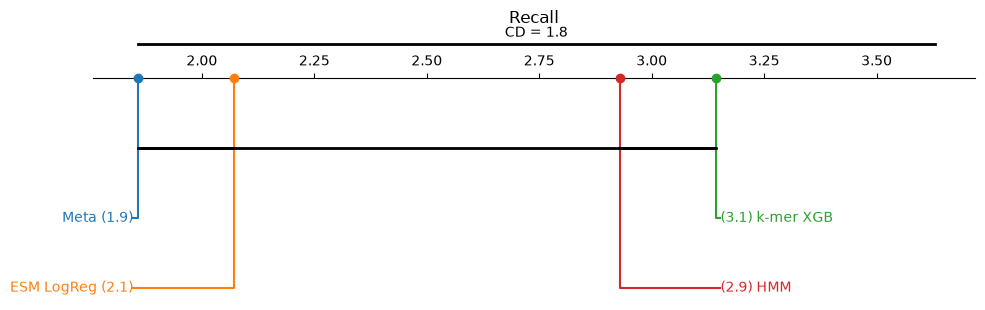

,n_folds,chi2,p_value,significant_at_0.05,best_average_rank
metric,,,,,
Accuracy,7,11.0571,0.0114,True,Meta
Precision,7,10.4559,0.0151,True,Meta
Recall,7,5.5714,0.1344,False,Meta


In [244]:
ALPHA = 0.05
METHODS = list(models.keys()) + ['HMM']

def _species_key(name):
    return str(name).split('_')[0]

fold_species = [_species_key(name) for name in models[METHODS[0]].fold_results.keys()]
hmm_species = hmm_fold_results['species'].astype(str).tolist()
if set(fold_species) != set(hmm_species):
    raise ValueError(f"Fold mismatch between ML models and HMM baseline: {fold_species} vs {hmm_species}")

metric_columns = {
    'Accuracy': 'val_accuracy',
    'Precision': 'val_precision',
    'Recall': 'val_recall',
}
scores_by_metric = {}
for metric_name, result_key in metric_columns.items():
    score_frame = pd.DataFrame({
        method: {
            _species_key(species): float(result[result_key])
            for species, result in evaluator.fold_results.items()
        }
        for method, evaluator in models.items()
    })
    hmm_values = hmm_fold_results.set_index('species')[metric_name.lower()].astype(float)
    score_frame['HMM'] = hmm_values.reindex(score_frame.index)
    score_frame = score_frame.reindex(columns=METHODS)
    if score_frame.isna().any().any():
        raise ValueError(f"Missing {metric_name} scores after fold alignment")
    scores_by_metric[metric_name] = score_frame

friedman_summary = []
nemenyi_results = {}
cd_values = {}
for metric_name, score_frame in scores_by_metric.items():
    statistic, p_value = friedmanchisquare(*[score_frame[method] for method in METHODS])
    ranks = score_frame.rank(axis=1, ascending=False, method='average')
    rank_means = ranks.mean(axis=0)
    nemenyi_pvalues = sp.posthoc_nemenyi_friedman(-score_frame)
    nemenyi_pvalues = nemenyi_pvalues.reindex(index=METHODS, columns=METHODS)
    n_blocks, n_methods = ranks.shape
    cd = studentized_range.ppf(1 - ALPHA, n_methods, np.inf) / np.sqrt(2) * np.sqrt(
        n_methods * (n_methods + 1) / (6 * n_blocks)
    )
    friedman_summary.append({
        'metric': metric_name,
        'n_folds': n_blocks,
        'chi2': statistic,
        'p_value': p_value,
        'significant_at_0.05': p_value < ALPHA,
        'best_average_rank': rank_means.idxmin(),
    })
    cd_values[metric_name] = cd
    nemenyi_results[metric_name] = nemenyi_pvalues if p_value < ALPHA else None
    if p_value < ALPHA:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
    else:
        print(f'{metric_name}: Friedman chi2={statistic:.3f}, p={p_value:.4g}')
        print('Omnibus test is not significant.')

    fig, ax = plt.subplots(figsize=(10, 3.2))
    sp.critical_difference_diagram(
        rank_means,
        nemenyi_pvalues,
        cd=cd,
        alpha=ALPHA,
        ax=ax,
        label_props={'fontsize': 10},
    )
    ax.set_title(metric_name)
    plt.tight_layout()
    plt.show()

friedman_summary_df = pd.DataFrame(friedman_summary).set_index('metric')
display(friedman_summary_df.round(4))

## Failure analysis

In [195]:
def get_miss_fp_sets(evaluator, threshold=0.5):
    misses, fps = set(), set()
    for details in evaluator.fold_details.values():
        pred_pos = details['pred'] >= threshold
        misses.update(details[(details['y_true']==1) & ~pred_pos]['id'])
        fps.update(details[(details['y_true']==0) & pred_pos]['id'])
    return misses, fps

all_evaluators = {
    'lr_esm': logreg_evaluator,
    'xgb_kmer': xgb_evaluator,
    'meta': meta_evaluator,
}

miss_sets = {}
fp_sets = {}
for name, ev in all_evaluators.items():
    m, f = get_miss_fp_sets(ev)
    miss_sets[name] = m
    fp_sets[name] = f

miss_counter = Counter()
for s in miss_sets.values():
    miss_counter.update(s)

fp_counter = Counter()
for s in fp_sets.values():
    fp_counter.update(s)

n_models = len(all_evaluators)
print(f"Misses by agreement level (out of {n_models} models):")
print(pd.Series(miss_counter.values()).value_counts().sort_index())
print(f"\nFPs by agreement level (out of {n_models} models):")
print(pd.Series(fp_counter.values()).value_counts().sort_index())

# majority (2 of 3) as "hard" cases
majority_misses = {k for k,v in miss_counter.items() if v >= 2}
majority_fps = {k for k,v in fp_counter.items() if v >= 2}
print(f"\nMajority (2+/3) misses: {len(majority_misses)}")
print(f"Majority (2+/3) FPs: {len(majority_fps)}")

xgb_pooled_probs = pd.concat(xgb_evaluator.fold_details.values()).set_index('id')
uncertain = xgb_pooled_probs[(xgb_pooled_probs['pred'] > 0.35) & (xgb_pooled_probs['pred'] < 0.65)]
print(f"{len(uncertain)} examples XGB is uncertain about")

Misses by agreement level (out of 3 models):
1    47
2    14
Name: count, dtype: int64

FPs by agreement level (out of 3 models):
1    65
2    25
Name: count, dtype: int64

Majority (2+/3) misses: 14
Majority (2+/3) FPs: 25
35 examples XGB is uncertain about


In [196]:
species_lookup = pd.Series(groups, index=X_kmer.index)

miss_species = species_lookup.reindex(list(majority_misses)).value_counts()
fp_species = species_lookup.reindex(list(majority_fps)).value_counts()

n_pos_by_species = pd.Series(y, index=X_kmer.index)[pd.Series(y, index=X_kmer.index) == 1] \
    .groupby(species_lookup).size()

error_species_df = pd.DataFrame({
    'misses': miss_species,
    'fps': fp_species,
    'n_pos': n_pos_by_species,
}).fillna(0).astype(int)

error_species_df['total_errors'] = error_species_df['misses'] + error_species_df['fps']
error_species_df['error_rate'] = error_species_df['total_errors'] / error_species_df['n_pos']

error_species_df = error_species_df[['total_errors', 'misses', 'fps', 'n_pos', 'error_rate']] \
    .sort_values('error_rate', ascending=False)

print(error_species_df)

                                                    total_errors  misses  fps  \
Slycopersicum_796_ITAG5.0.protein_primaryTransc...             9       2    7   
Athaliana_447_Araport11.protein_primaryTranscri...             4       1    3   
Vvinifera_457_v2.1.protein_primaryTranscriptOnly              11       1   10   
Fvesca_226_v1.1.protein_primaryTranscriptOnly                  1       1    0   
Osativa_204_v7.0.protein_primaryTranscriptOnly                 4       4    0   
Gmax_189_protein_primaryTranscriptOnly                         6       3    3   
Pvulgaris_442_v2.1.protein_primaryTranscriptOnly               4       2    2   

                                                    n_pos  error_rate  
Slycopersicum_796_ITAG5.0.protein_primaryTransc...     17    0.529412  
Athaliana_447_Araport11.protein_primaryTranscri...     13    0.307692  
Vvinifera_457_v2.1.protein_primaryTranscriptOnly      104    0.105769  
Fvesca_226_v1.1.protein_primaryTranscriptOnly          10    0.

### Inspect tomato

In [197]:
sly_mask = species_lookup.str.startswith('Slycopersicum')
sly_errors = (majority_misses | majority_fps) & set(species_lookup[sly_mask].index)
for e in sly_errors:
    print(e)

Solyc01T000282.1
Solyc01T000275.1
Solyc11T000232.1
Solyc12T002359.1
Solyc11T000233.1
Solyc10T000016.1
Solyc02T001670.1
Solyc05T000170.1
Solyc09T000267.1


## --------------------------------------

## PU-clean full dataset

In [198]:
if RUN_PU:
    pos_idx_full = np.where(y_deduped == 1)[0]
    neg_idx_full = np.where(y_deduped == 0)[0]

    pu_scores_full, n_oob_full = run_pu_bagging(
        X_deduped_kmer, y_deduped, pos_idx_full, neg_idx_full,
        n_iter=N_ITER, neg_sample_ratio=NEG_SAMPLE_RATIO, seed=2026,
    )
    flagged_full_mask = pu_scores_full >= 0.8
    flagged_full_ids = set(X_deduped_kmer.index[neg_idx_full[flagged_full_mask]])

    print(f'{len(flagged_full_ids)} proteins flagged for removal (pu_score >= 0.8)')

    clean_mask_full = ~X_deduped_kmer.index.isin(flagged_full_ids)
    X_clean_full = X_deduped_kmer[clean_mask_full]
    y_clean_full = y_deduped[clean_mask_full]
    groups_clean_full = groups_deduped[clean_mask_full]

    print(f'{len(y_deduped) - len(y_clean_full)} proteins removed')
    print(f'{y_clean_full.sum()} positives remain, {(y_clean_full == 0).sum()} negatives remain')
else:
    print('Did not run PU')
    X_clean_full = X_deduped_kmer.copy()
    y_clean_full = y_deduped.copy()
    groups_clean_full = groups_deduped.copy()

KeyboardInterrupt: 

## Full model

Build a full model using all species and analyze features. Could also be used for extra test inference in the future.

### Fit full model

In [ ]:
scale_pos_weight_full = get_scale_pos_weight(y_clean_full)

model_full = make_model(scale_pos_weight_full)
model_full.fit(X_clean_full, y_clean_full)

print(f'{(y_clean_full == 1).sum()} positives, {(y_clean_full == 0).sum()} negatives')
print(f'scale_pos_weight_full = {scale_pos_weight_full:.2f}')

### Feature importance

In [ ]:
importances = model_full.feature_importances_
imp_df = pd.DataFrame({
    'kmer': X_clean_full.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

display(imp_df.head())

## Misc analysis

### Model quality / complexity

#### Species-count curve

"Does including more species in training improve the model?"

In [ ]:
RUN_SPECIES_COUNT_CURVE = False  #@param {type:"boolean"}

In [ ]:
if RUN_SPECIES_COUNT_CURVE:
    species_list = sorted(set(groups_deduped))
    species_curve_rows = []

    for held_out in species_list:
        other_species = [s for s in species_list if s != held_out]
        val_mask = groups_deduped == held_out
        X_val, y_val = X_deduped_kmer[val_mask], y_deduped[val_mask]

        for k in range(1, len(other_species) + 1):
            for combo in combinations(other_species, k):
                train_mask = np.isin(groups_deduped, combo)
                X_train, y_train = X_deduped_kmer[train_mask], y_deduped[train_mask]
                if y_train.sum() == 0:
                    continue

                m = make_model((y_train == 0).sum() / y_train.sum())
                m.fit(X_train, y_train)
                preds = m.predict_proba(X_val)[:, 1]
                score = average_precision_score(y_val, preds)

                species_curve_rows.append({
                    'held_out': held_out.split('_')[0],
                    'n_train_species': k,
                    'train_species': ','.join(s.split('_')[0] for s in combo),
                    'val_pr_auc': score,
                })

    species_curve_df = pd.DataFrame(species_curve_rows)

    fig, ax = plt.subplots(figsize=(7, 4))
    for held_out, grp in species_curve_df.groupby('held_out'):
        agg = grp.groupby('n_train_species')['val_pr_auc'].mean()
        ax.plot(agg.index, agg.values, marker='o', label=held_out)
    ax.set_xlabel('Number of training species')
    ax.set_ylabel('Val PR-AUC (mean over species combos)')
    ax.legend()
    plt.show()

#### Baseline cosine

Establish a baseline using cosine similarity instead of a model.

"Does XGBoost actually need the complexity?"

In [ ]:
cos_fold_results = {}

for train_idx, val_idx in logo.split(X_deduped_kmer, y_deduped, groups=groups_deduped):
    held_out_species = groups_deduped[val_idx][0]
    n_pos_val = y_deduped[val_idx].sum()
    n_total_val = len(val_idx)
    baseline = n_pos_val / n_total_val

    X_train = X_deduped_kmer.iloc[train_idx]
    X_val = X_deduped_kmer.iloc[val_idx]

    centroid = X_train[y_deduped[train_idx] == 1].mean(axis=0)
    similarity_scores = cosine_similarity(X_val, centroid.values.reshape(1, -1)).flatten()
    score = average_precision_score(y_deduped[val_idx], similarity_scores)
    lift = score / baseline

    cos_fold_results[held_out_species] = {
        'baseline': baseline,
        'pr_auc': score,
        'lift': lift,
        'n_pos': n_pos_val,
    }

cos_results_df = pd.DataFrame(cos_fold_results).T
cos_results_df

#### Logistic regression for species identity

Check for potential phylogenetic leak rather than data leak.

"Is species identity easily identifiable from k-mer features?"

In [ ]:
species_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=1000,
        random_state=2026,
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)
scores = cross_val_score(species_clf, X_deduped_kmer, groups_deduped, cv=cv, scoring='accuracy')

print(f'Species prediction accuracy (5-fold CV): {scores.mean():.3f} +/- {scores.std():.3f}')
print(f'Chance baseline (majority class): {pd.Series(groups_deduped).value_counts(normalize=True).max():.3f}')
print(f'Chance baseline (random guess, {len(set(groups_deduped))} classes): {1/len(set(groups_deduped)):.3f}')

### K-mer matrix similarity

#### Inter-species

In [ ]:
pos_mask = y_deduped == 1
X_pos = X_deduped_kmer[pos_mask]
species_pos = groups_deduped[pos_mask]
ids_pos = X_pos.index

sim_matrix = cosine_similarity(X_pos)

rows = []
for i in range(len(ids_pos)):
    for j in range(i+1, len(ids_pos)):
        if species_pos[i] != species_pos[j]:
            rows.append({
                'protein_a': ids_pos[i],
                'protein_b': ids_pos[j],
                'similarity': sim_matrix[i, j],
            })

sim_df = pd.DataFrame(rows).sort_values('similarity', ascending=False)
sim_df.head()

#### Intra-species, positive

In [ ]:
within_species_pos_rows = []

for species in sorted(set(groups_deduped)):
    mask = (groups_deduped == species) & (y_deduped == 1)
    X_sub = X_deduped_kmer[mask]
    ids_sub = X_sub.index
    if len(ids_sub) < 2:
        continue

    sim = cosine_similarity(X_sub)
    for i in range(len(ids_sub)):
        for j in range(i + 1, len(ids_sub)):
            within_species_pos_rows.append({
                'species': species.split('_')[0],
                'protein_a': ids_sub[i],
                'protein_b': ids_sub[j],
                'similarity': sim[i, j],
            })

within_species_pos_sim = pd.DataFrame(within_species_pos_rows)
top_intra_sim = within_species_pos_sim[within_species_pos_sim['similarity'] >= 0.95].sort_values('similarity', ascending=False)
print(len(top_intra_sim))
top_intra_sim

#### Intra-species, negative, random sample

In [ ]:
rng = np.random.default_rng(2026)

def sampled_pairwise_sim(X_sub, ids_sub, n_pairs=2000):
    n = len(ids_sub)
    vecs = X_sub.values
    idx_a = rng.integers(0, n, size=n_pairs)
    idx_b = rng.integers(0, n, size=n_pairs)
    keep = idx_a != idx_b
    idx_a, idx_b = idx_a[keep], idx_b[keep]

    num = np.sum(vecs[idx_a] * vecs[idx_b], axis=1)
    denom = np.linalg.norm(vecs[idx_a], axis=1) * np.linalg.norm(vecs[idx_b], axis=1)
    sims = np.divide(num, denom, out=np.zeros_like(num), where=denom > 0)

    return pd.DataFrame({
        'protein_a': ids_sub[idx_a],
        'protein_b': ids_sub[idx_b],
        'similarity': sims,
    })

baseline_rows = []
for species in sorted(set(groups_deduped)):
    mask = (groups_deduped == species) & (y_deduped == 0)
    X_sub = X_deduped_kmer[mask]
    ids_sub = X_sub.index
    df = sampled_pairwise_sim(X_sub, ids_sub, n_pairs=2000)
    df['species'] = species.split('_')[0]
    baseline_rows.append(df)

baseline_neg_sim = pd.concat(baseline_rows, ignore_index=True)
baseline_neg_sim.sort_values('similarity', ascending=False).head(10)

#### Cosine similarity distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (df, title) in zip(axes, [
    (within_species_pos_sim, 'Positive-positive (within species)'),
    (baseline_neg_sim, 'Negative-negative (within species, sampled)'),
]):
    for species, grp in df.groupby('species'):
        ax.hist(grp['similarity'], bins=30, alpha=0.2, label=species)
    ax.set_title(title)
    ax.set_xlabel('Cosine similarity')

axes[0].set_ylabel('Count')
axes[0].legend()
plt.tight_layout()
plt.show()